<a href="https://colab.research.google.com/github/mehedihasan-cse/GDELT-Project/blob/main/GDELT_Code_Exploration_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UK Inflation News Analysis: Final Process-Aligned Notebook

This notebook implements the final analytical workflow used for the dissertation. It keeps three measurement tasks separate:

1. **InflaBERT** measures inflation direction using the three classes **DOWN / NEUTRAL / UP** and a continuous polarity score \(P(UP)-P(DOWN)\).
2. **GPT directional labels** use the same \(-1/0/+1\) inflation-direction axis and provide a second automated directional measure.
3. **GDELT V2Tone** is retained as a **general document-tone baseline**. Its positive/negative sign is not treated as equivalent to inflation UP/DOWN.
4. **ONS CPI** is transformed using the first log difference to represent month-to-month inflation movement.
5. Economic evaluation is limited to **contemporaneous correlation and 0–3 month lead-lag correlation**.
6. InflaBERT and GPT are evaluated against the supplied **reference annotation sample** using Accuracy, Macro Precision, Macro Recall, Macro F1, Balanced Accuracy, Cohen's kappa and confusion matrices.


## 1. Environment and reproducibility

All analysis imports, label mappings and reproducibility settings are defined once. Report-output saving is **disabled by default** in this version so the notebook can be run without creating files. When report files are needed, uncomment the `OUTPUT_DIR` lines and the relevant save commands.


In [ ]:
from pathlib import Path
from io import StringIO
import html
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import torch
import torch.nn.functional as F

from scipy.stats import pearsonr
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Optional report-output folder.
# Uncomment these two lines only when you want figures/tables saved to files.
# OUTPUT_DIR = Path('/content/report_outputs')
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Inflation-direction convention used for the reference labels, GPT and InflaBERT.
DIRECTION_NAME = {-1: 'DOWN', 0: 'NEUTRAL', 1: 'UP'}

# GDELT is general document tone, not inflation direction.
GDELT_TONE_NAME = {-1: 'NEGATIVE', 0: 'NEUTRAL', 1: 'POSITIVE'}

def label_to_num(value):
    """Map numeric or text inflation-direction labels onto -1 / 0 / +1."""
    if pd.isna(value):
        return np.nan

    if isinstance(value, (int, float, np.integer, np.floating)):
        if float(value) in (-1.0, 0.0, 1.0):
            return int(value)

    text_value = str(value).strip().lower()
    mapping = {
        '-1': -1, 'negative': -1, 'down': -1, 'downward': -1,
        '0': 0, 'neutral': 0,
        '1': 1, '+1': 1, 'positive': 1, 'up': 1, 'upward': 1
    }
    return mapping.get(text_value, np.nan)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
# print('Report-output saving is currently disabled (OUTPUT_DIR is commented out).')


Device: cuda


## 2. Data access

The main article dataset contains GDELT metadata, extracted article text and the pre-existing GPT inflation-direction label. The validation workbook is loaded later in the notebook.

The code checks both `/content` and a typical Google Drive project folder, so the notebook can be run after either uploading the files directly to Colab or placing them in Drive.

In [ ]:
# Optional Google Drive mount for Colab
# try:
#     from google.colab import drive
#     drive.mount('/content/drive')
# except Exception:
#     print('Google Drive mount skipped (not running in Colab or Drive unavailable).')

In [ ]:
MAIN_DATA_CANDIDATES = [
    Path('/content/GPT 5.5 Labeled Data.csv')
    # ,
    # Path('/content/drive/MyDrive/GDELT/GPT 5.5 Labeled Data.csv')
]

main_data_path = next((p for p in MAIN_DATA_CANDIDATES if p.exists()), None)

# if main_data_path is None:
#     raise FileNotFoundError(
#         'Main dataset not found. Upload "GPT 5.5 Labeled Data.csv" to /content '
#         'or place it in /content/drive/MyDrive/GDELT/.'
#     )

raw_df = pd.read_csv(main_data_path)

# Standardise the GPT column name while keeping an unfiltered lookup copy for validation.
if 'GPT_Label' not in raw_df.columns and 'Inflation_Label' in raw_df.columns:
    raw_df = raw_df.rename(columns={'Inflation_Label': 'GPT_Label'})

raw_df['GPT_Label'] = raw_df['GPT_Label'].apply(label_to_num)

df = raw_df.copy()

print(f'Loaded {len(df):,} article rows from: {main_data_path}')
print(f'Columns available: {len(df.columns)}')
display(df[['ArticleDate', 'Month', 'SourceCommonName', 'Headline', 'GPT_Label']].head())

Loaded 10,517 article rows from: /content/GPT 5.5 Labeled Data.csv
Columns available: 27


,ArticleDate,Month,SourceCommonName,Headline,GPT_Label
0,2025-02-07,2025-02,sky.com,Billions for 'unproven' carbon capture technol...,0.0
1,2026-03-11,2026-03,sky.com,Iran war: The outlook for your finances - whet...,0.0
2,2024-09-24,2024-09,sky.com,Brent crude prices rise amid Israeli air strik...,0.0
3,2024-10-22,2024-10,sky.com,UK economic forecast boosted by IMF,0.0
4,2024-06-18,2024-06,sky.com,Money blog: Smoke machines deployed in Tesco; ...,0.0


## 3. Source and extraction-quality screening

Non-UK domains identified during the exploratory phase are removed by source rule rather than by sentiment. Failed-access pages and empty extractions are removed. Text cleaning is deliberately light: HTML entities/tags, a small number of obvious encoding artefacts and technical page boilerplate are cleaned while punctuation, case and economically meaningful wording are retained.

Only **exact duplicate article rows** (same date, headline and cleaned extracted text) are removed from the main corpus. This avoids counting the same record twice without removing legitimately repeated coverage of the same story by different outlets.


In [ ]:
non_uk_domains = [
    'eastmoney.com',
    'insidermonkey.com',
    'ey.com',
    'infomoney.com.br',
    'skynews.com.au',
    'fortuneturkey.com',
    'insideottawavalley.com'
]

before = len(df)
df = df[~df['SourceCommonName'].isin(non_uk_domains)].copy()
print(f'Removed {before - len(df):,} rows from identified non-UK domains.')

Removed 47 rows from identified non-UK domains.


In [ ]:
# Core date alignment
df['ArticleDate'] = pd.to_datetime(df['ArticleDate'], errors='coerce')
df['Month_Date'] = pd.to_datetime(df['Month'], format='%Y-%m', errors='coerce')
df['ArticleDate'] = df['ArticleDate'].fillna(df['Month_Date'])
df['Month_Key'] = df['Month_Date'].dt.strftime('%Y-%m')

# Keep the final project period
df = df[df['ArticleDate'] >= pd.Timestamp('2024-01-01')].copy()

# Remove rows without usable article text
df = df.dropna(subset=['Extracted_Text']).copy()

access_issue_pattern = re.compile(
    r'^Access Issue Help\s+You are seeing this page because our security systems',
    flags=re.IGNORECASE
)
df = df[
    ~df['Extracted_Text'].astype(str).str.contains(access_issue_pattern, na=False)
].copy()

def light_clean_text(text):
    """Light cleaning only: decode web artefacts without removing economic content."""
    if pd.isna(text):
        return ''

    text = str(text)

    # Decode HTML entities such as &#xA3; and &#x2026;.
    text = html.unescape(html.unescape(text))

    # Fix a small set of common extraction/encoding artefacts found in this corpus.
    replacements = {
        '‚Äô': '’', '‚Äò': '‘',
        '‚Äú': '“', '‚Äù': '”',
        '‚Äì': '–', '‚Äî': '—', '‚Ä¶': '…',
        '¬£': '£', 'Â£': '£', 'Â': ''
    }
    for old, new in replacements.items():
        text = text.replace(old, new)

    # Remove HTML tags and obvious technical webpage boilerplate only.
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(
        r'You need javascript enabled to view this content(?:\s+\d+:\d+)?(?:\s+Enable javascript to share Share)?',
        ' ', text, flags=re.IGNORECASE
    )
    text = re.sub(
        r'Your browser does not support iframes\.?',
        ' ', text, flags=re.IGNORECASE
    )

    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Extracted_Text'] = df['Extracted_Text'].apply(light_clean_text)

# Remove empty strings created by cleaning
df = df[df['Extracted_Text'].str.len() > 0].copy()

# Conservative duplicate removal: only identical article records are removed.
before_dedup = len(df)
df = df.drop_duplicates(
    subset=['ArticleDate', 'Headline', 'Extracted_Text'],
    keep='first'
).copy()
print(f'Removed {before_dedup - len(df):,} exact duplicate article rows.')

print(f'Final analysis corpus: {len(df):,} articles')
print(f'Timeline: {df["Month_Key"].min()} to {df["Month_Key"].max()}')
print(f'Unique sources: {df["SourceCommonName"].nunique():,}')


Removed 30 exact duplicate article rows.
Final analysis corpus: 10,094 articles
Timeline: 2024-01 to 2026-06
Unique sources: 17


### Monthly coverage

Article counts are checked before modelling to make gaps or unusual media-volume months visible. This is a data-quality diagnostic rather than an inflation result.

,Article_Count
Month_Key,
2024-01,436
2024-02,381
2024-03,444
2024-04,359
2024-05,386
2024-06,297
2024-07,327
2024-08,282
2024-09,318


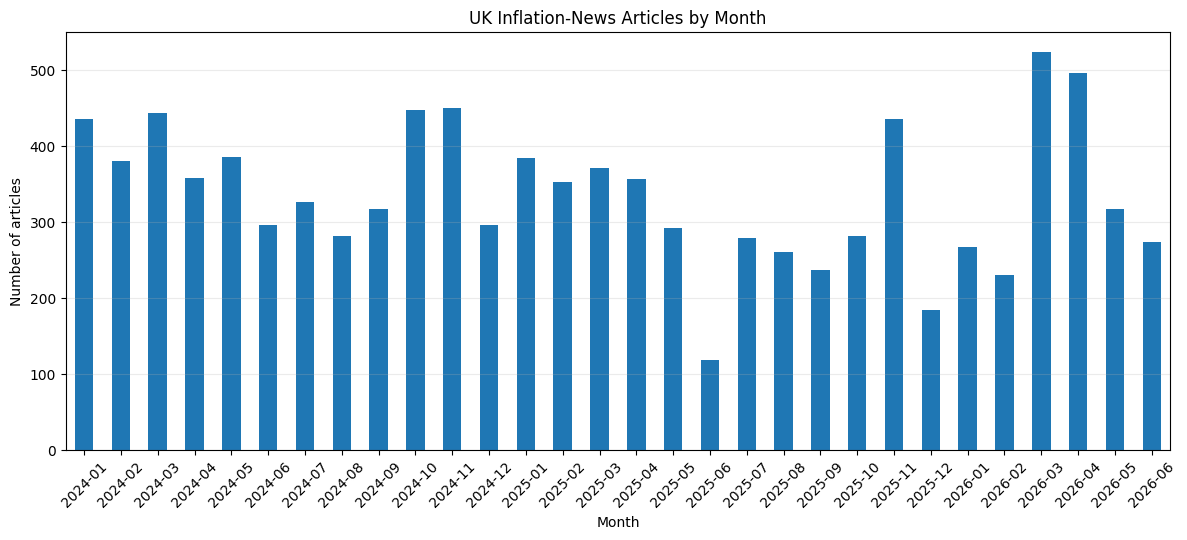

In [ ]:
monthly_counts = (
    df.groupby('Month_Key')
      .size()
      .rename('Article_Count')
)

display(monthly_counts.to_frame())

ax = monthly_counts.plot(kind='bar', figsize=(12, 5.5), color='C0')
ax.set_title('UK Inflation-News Articles by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Number of articles')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 4. InflaBERT directional scoring

InflaBERT is used as an inflation-direction model. The saved model configuration is inspected before inference so the class ids are not silently assumed.

For each article window, logits are converted to probabilities using softmax. Long articles are processed with overlapping windows. Article-level probabilities are the mean across windows, and the continuous directional index is:

\[
\text{InflaBERT Polarity}=P(UP)-P(DOWN)
\]

The categorical label is the class with the highest probability.

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

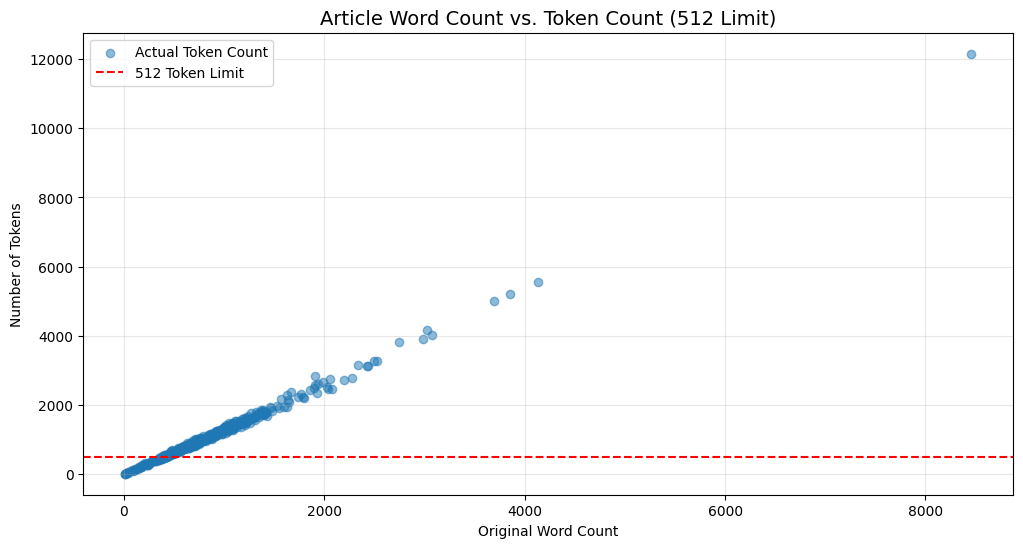

On average, 512 tokens covers approximately 2416 characters.
Articles above the red line are currently being truncated (cut off).


In [ ]:
import matplotlib.pyplot as plt
from transformers import BertTokenizer, AutoTokenizer # Ensure BertTokenizer is imported

# Define fin_tokenizer here to ensure it's available
fin_model_name = 'yiyanghkust/finbert-tone'
fin_tokenizer = BertTokenizer.from_pretrained(fin_model_name)

# We will use the FinBERT tokenizer as a proxy for the 512 token limit
def get_token_cutoff_info(text, limit=512):
    if not isinstance(text, str): return 0, 0
    tokens = fin_tokenizer.tokenize(text)
    # Get the text represented by only the first 512 tokens
    truncated_text = fin_tokenizer.convert_tokens_to_string(tokens[:limit])
    return len(truncated_text), len(tokens)

# Sample a subset to save time if the DF is large
sample_df = df.sample(min(500, len(df))).copy()
cutoff_data = sample_df['Extracted_Text'].apply(get_token_cutoff_info)
sample_df['Char_Length_at_512'], sample_df['Total_Tokens'] = zip(*cutoff_data)

# Visualization
plt.figure(figsize=(12, 6))
plt.scatter(sample_df['Word_Count'], sample_df['Total_Tokens'], alpha=0.5, label='Actual Token Count')
plt.axhline(y=512, color='r', linestyle='--', label='512 Token Limit')

plt.title('Article Word Count vs. Token Count (512 Limit)', fontsize=14)
plt.xlabel('Original Word Count')
plt.ylabel('Number of Tokens')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Summary stats
avg_chars = sample_df[sample_df['Total_Tokens'] > 512]['Char_Length_at_512'].mean()
print(f"On average, 512 tokens covers approximately {avg_chars:.0f} characters.")
print(f"Articles above the red line are currently being truncated (cut off).")

In [ ]:
inf_model_name = 'MAPAi/InflaBERT'
inf_tokenizer = AutoTokenizer.from_pretrained(inf_model_name)
inf_model = AutoModelForSequenceClassification.from_pretrained(inf_model_name).to(device).eval()

print('InflaBERT id2label:', inf_model.config.id2label)

def resolve_infla_label_ids(id2label):
    clean = {int(k): str(v).strip().lower() for k, v in id2label.items()}

    def find_id(words):
        for idx, name in clean.items():
            if any(word in name for word in words):
                return idx
        return None

    down_id = find_id(['negative', 'down'])
    neutral_id = find_id(['neutral'])
    up_id = find_id(['positive', 'up'])

    if None in (down_id, neutral_id, up_id):
        print('Generic label names detected; using documented order 0=DOWN, 1=NEUTRAL, 2=UP.')
        down_id, neutral_id, up_id = 0, 1, 2

    return down_id, neutral_id, up_id

DOWN_ID, NEUTRAL_ID, UP_ID = resolve_infla_label_ids(inf_model.config.id2label)
print(f'Resolved ids: DOWN={DOWN_ID}, NEUTRAL={NEUTRAL_ID}, UP={UP_ID}')

def get_softmax_sentiment(text, max_length=512, stride=256):
    if not isinstance(text, str) or not text.strip():
        return 0.0, 1.0, 0.0, 0.0

    token_ids = inf_tokenizer.encode(text, add_special_tokens=False)
    content_window = max_length - 2

    def score_window(window_token_ids):
        # Manually add BOS and EOS tokens for Roberta-based models
        # BOS = tokenizer.cls_token_id, EOS = tokenizer.sep_token_id
        cls_id = inf_tokenizer.cls_token_id
        sep_id = inf_tokenizer.sep_token_id

        full_ids = [cls_id] + window_token_ids + [sep_id]

        # Pad to max_length if necessary
        pad_id = inf_tokenizer.pad_token_id
        if len(full_ids) < max_length:
            full_ids = full_ids + [pad_id] * (max_length - len(full_ids))

        input_ids = torch.tensor([full_ids]).to(device)
        # Mask is 0 where input is pad_id, 1 otherwise
        attention_mask = (input_ids != pad_id).long().to(device)

        with torch.no_grad():
            logits = inf_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            ).logits

        return F.softmax(logits, dim=-1).cpu().numpy()[0]

    if len(token_ids) <= content_window:
        probs = score_window(token_ids)
    else:
        window_probs = []
        for start in range(0, len(token_ids), stride):
            window = token_ids[start:start + content_window]
            if len(window) < 32:
                break
            window_probs.append(score_window(window))

        probs = np.mean(window_probs, axis=0)

    p_down = float(probs[DOWN_ID])
    p_neutral = float(probs[NEUTRAL_ID])
    p_up = float(probs[UP_ID])

    return p_down, p_neutral, p_up, p_up - p_down

config.json:   0%|          | 0.00/980 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.41k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  328MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

InflaBERT id2label: {0: 'negative', 1: 'neutral', 2: 'positive'}
Resolved ids: DOWN=0, NEUTRAL=1, UP=2


## 5. Article-level scoring and directional labels

GDELT's first `V2Tone` component is retained on its native scale as general document tone. InflaBERT and GPT, in contrast, are directional measures and can be compared descriptively on the shared DOWN / NEUTRAL / UP axis.

In [ ]:
def extract_v2tone(value):
    try:
        return float(str(value).split(',')[0])
    except (TypeError, ValueError):
        return np.nan

df['GDELT_Tone'] = df['V2Tone'].apply(extract_v2tone)

print(f'Scoring {len(df):,} articles with InflaBERT...')
start_time = time.time()

results = df['Extracted_Text'].apply(get_softmax_sentiment)
df['P_DOWN'], df['P_NEUTRAL'], df['P_UP'], df['InflaBERT_Polarity'] = zip(*results)

prob_cols = ['P_DOWN', 'P_NEUTRAL', 'P_UP']
direction_values = np.array([-1, 0, 1])

df['InflaBERT_Predicted_Label'] = direction_values[
    np.argmax(df[prob_cols].to_numpy(), axis=1)
]

df['GPT_Label'] = df['GPT_Label'].apply(label_to_num)

elapsed = (time.time() - start_time) / 60
print(f'InflaBERT scoring complete in {elapsed:.2f} minutes.')
display(
    df[['Headline', 'InflaBERT_Predicted_Label', 'GPT_Label',
        'InflaBERT_Polarity', 'GDELT_Tone']].head(10)
)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (562 > 512). Running this sequence through the model will result in indexing errors


Scoring 10,094 articles with InflaBERT...
InflaBERT scoring complete in 13.20 minutes.


,Headline,InflaBERT_Predicted_Label,GPT_Label,InflaBERT_Polarity,GDELT_Tone
0,Billions for 'unproven' carbon capture technol...,0,0,-0.468270,0.228311
1,Iran war: The outlook for your finances - whet...,1,0,0.829696,-2.986162
2,Brent crude prices rise amid Israeli air strik...,0,0,-0.467308,-4.297994
3,UK economic forecast boosted by IMF,-1,0,-0.966446,-1.418440
4,Money blog: Smoke machines deployed in Tesco; ...,-1,0,-0.868918,1.111111
5,Protesters in Kenya are tired of double standa...,0,0,0.000562,-6.635071
6,Rate cut bets rise on evidence of slowing serv...,-1,0,-0.948732,-2.320675
7,Energy: Mine water heat could cut bills for th...,0,0,0.000012,1.379310
8,Rent Rises: 'Unaffordable' rises pricing rente...,1,0,0.995429,-0.173611
9,DAN HODGES: Five years ago I could sense the r...,0,0,-0.003768,-2.711864


### Article-level distribution: inflation direction and GDELT tone

This chart is a **measurement diagnostic, not an accuracy test**. InflaBERT and GPT use **DOWN / NEUTRAL / UP** because they target inflation direction. GDELT uses **NEGATIVE / NEUTRAL / POSITIVE** because it measures general document tone. The three positions are shown side by side only to compare their empirical distributions; GDELT tone is not interpreted as inflation direction.


--- Article-Level Class / Tone Share (%) ---


,InflaBERT,GPT
DOWN,12.81,1.01
NEUTRAL,63.32,95.80
UP,23.87,3.19


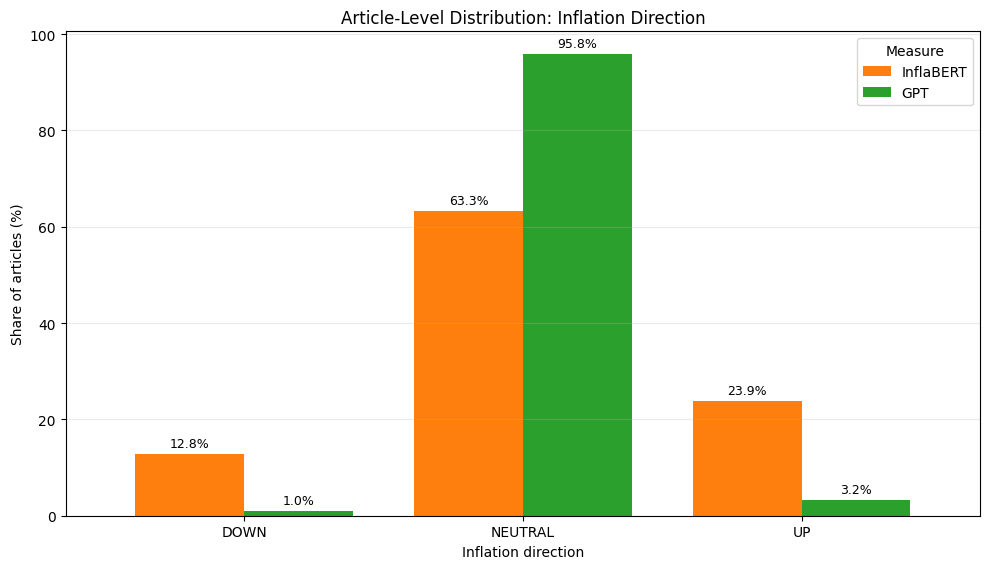

In [ ]:
# InflaBERT and GPT: inflation direction (DOWN / NEUTRAL / UP)
infla_dist = (
    df['InflaBERT_Predicted_Label']
    .map(DIRECTION_NAME)
    .value_counts(normalize=True)
    .reindex(['DOWN', 'NEUTRAL', 'UP'], fill_value=0) * 100
)

gpt_dist = (
    df['GPT_Label']
    .map(DIRECTION_NAME)
    .value_counts(normalize=True)
    .reindex(['DOWN', 'NEUTRAL', 'UP'], fill_value=0) * 100
)

distribution_df = pd.DataFrame(
    {
        'InflaBERT': infla_dist.to_numpy(),
        'GPT': gpt_dist.to_numpy()
    },
    index=['DOWN', 'NEUTRAL', 'UP']
)

print('--- Article-Level Class / Tone Share (%) ---')
display(distribution_df.round(2))

# Setting colors: InflaBERT=Orange (C1), GPT=Green (C2)
ax = distribution_df.plot(kind='bar', figsize=(10, 5.8), width=0.78, color=['C1', 'C2'])
ax.set_title('Article-Level Distribution: Inflation Direction')
ax.set_xlabel('Inflation direction')
ax.set_ylabel('Share of articles (%)')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Measure')

for patch in ax.patches:
    height = patch.get_height()
    if np.isfinite(height) and height > 0:
        ax.annotate(
            f'{height:.1f}%',
            (patch.get_x() + patch.get_width()/2, height),
            ha='center', va='bottom', fontsize=9,
            xytext=(0, 3), textcoords='offset points'
        )

plt.tight_layout()
plt.show()

In [ ]:
# Calculate exact counts for InflaBERT and GPT labels
infla_counts = df['InflaBERT_Predicted_Label'].map(DIRECTION_NAME).value_counts().reindex(['DOWN', 'NEUTRAL', 'UP'], fill_value=0)
gpt_counts = df['GPT_Label'].map(DIRECTION_NAME).value_counts().reindex(['DOWN', 'NEUTRAL', 'UP'], fill_value=0)

# Create a summary table for absolute counts
counts_df = pd.DataFrame({
    'InflaBERT_Count': infla_counts,
    'GPT_Count': gpt_counts
})

print(f'--- Absolute Article Counts (Total N={len(df):,}) ---')
display(counts_df)

--- Absolute Article Counts (Total N=10,094) ---


,InflaBERT_Count,GPT_Count
DOWN,1293,102
NEUTRAL,6392,9670
UP,2409,322


--- GDELT Tone Summary ---


,GDELT_Tone
count,10094.000
mean,-1.610
std,2.370
min,-17.647
25%,-3.103
50%,-1.594
75%,-0.134
max,16.667


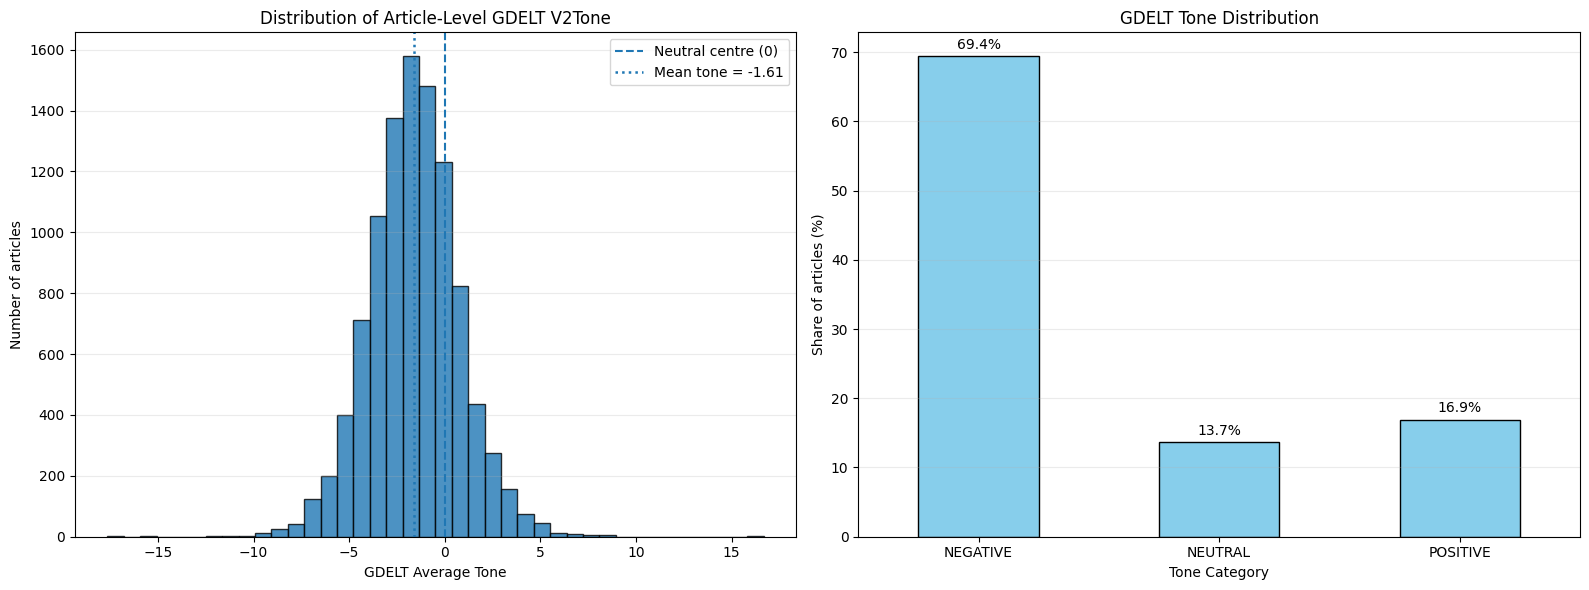

In [ ]:
# --- Article-level GDELT V2Tone distribution ---

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

gdelt_tone = pd.to_numeric(df['GDELT_Tone'], errors='coerce').dropna()

print('--- GDELT Tone Summary ---')
display(gdelt_tone.describe().to_frame('GDELT_Tone').round(3))

# 1. Continuous Histogram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.hist(gdelt_tone, bins=40, edgecolor='black', alpha=0.8)
ax1.axvline(0, linestyle='--', linewidth=1.5, label='Neutral centre (0)')
gdelt_mean = gdelt_tone.mean()
ax1.axvline(gdelt_mean, linestyle=':', linewidth=1.8, label=f'Mean tone = {gdelt_mean:.2f}')
ax1.set_title('Distribution of Article-Level GDELT V2Tone')
ax1.set_xlabel('GDELT Average Tone')
ax1.set_ylabel('Number of articles')
ax1.grid(axis='y', alpha=0.25)
ax1.legend()

# 2. Categorical Heuristic (Three Labels)
# Threshold: < -0.5 = Negative, > 0.5 = Positive, else Neutral
def tone_heuristic(val):
    if val < -0.5: return 'NEGATIVE'
    elif val > 0.5: return 'POSITIVE'
    else: return 'NEUTRAL'

gdelt_categories = gdelt_tone.apply(tone_heuristic)
cat_dist = gdelt_categories.value_counts(normalize=True).reindex(['NEGATIVE', 'NEUTRAL', 'POSITIVE'], fill_value=0) * 100

cat_dist.plot(kind='bar', ax=ax2, color='skyblue', edgecolor='black')
ax2.set_title('GDELT Tone Distribution')
ax2.set_ylabel('Share of articles (%)')
ax2.set_xlabel('Tone Category')
ax2.tick_params(axis='x', rotation=0)
ax2.grid(axis='y', alpha=0.25)

for patch in ax2.patches:
    height = patch.get_height()
    ax2.annotate(f'{height:.1f}%', (patch.get_x() + patch.get_width()/2, height),
                 ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

In [ ]:
# Calculate exact counts for GDELT Tone categories
gdelt_counts = gdelt_categories.value_counts().reindex(['NEGATIVE', 'NEUTRAL', 'POSITIVE'], fill_value=0)

# Create a summary table for GDELT absolute counts
gdelt_counts_df = gdelt_counts.to_frame(name='Article_Count')

print(f'--- GDELT Absolute Article Counts (Total N={len(gdelt_tone):,}) ---')
display(gdelt_counts_df)


--- GDELT Absolute Article Counts (Total N=10,094) ---


,Article_Count
GDELT_Tone,
NEGATIVE,7004
NEUTRAL,1383
POSITIVE,1707


Disagrrements of GDELT and Models

In [ ]:
# 1. Broaden the filter to capture more examples for insight
disagreement_up = df[
    (df['GDELT_Tone'] < -1) &
    (df['InflaBERT_Predicted_Label'] == 1) &
    (df['GPT_Label'] == 1)
].copy()

disagreement_down = df[
    (df['GDELT_Tone'] > 1) &
    (df['InflaBERT_Predicted_Label'] == -1) &
    (df['GPT_Label'] == -1)
].copy()

print(f"Found {len(disagreement_up)} cases of GDELT-Negative/Models-UP")
print(f"Found {len(disagreement_down)} cases of GDELT-Positive/Models-DOWN\n")

# 2. Insights: Qualitative Review of Text
print("--- INSIGHT 1: Qualitative Text Review (Disagreement Up) ---")
# Displaying the first 200 characters to see the 'framing'
for i, row in disagreement_up.head(3).iterrows():
    print(f"DATE: {row['ArticleDate']} | GDELT: {row['GDELT_Tone']:.2f}")
    print(f"HEADLINE: {row['Headline']}")
    print(f"TEXT SNIPPET: {row['Extracted_Text'][:300]}...\n")

# 3. Insights: Lexical Frequency (What words drive the GDELT score?)
from collections import Counter
import re

def get_common_words(text_series):
    all_text = " ".join(text_series.astype(str)).lower()
    words = re.findall(r'\w+', all_text)
    # Filter out common stop words manually to keep it light
    stops = {'the', 'a', 'and', 'to', 'of', 'in', 'is', 'for', 'on', 'that', 'with', 'as', 'at', 'it'}
    return Counter([w for w in words if w not in stops and len(w) > 3]).most_common(10)

print("--- INSIGHT 2: Key Terms in GDELT-Negative/Models-UP ---")
print(get_common_words(disagreement_up['Extracted_Text']))

print("\n--- INSIGHT 3: Statistical Comparison of the Disagreement ---")
display(pd.DataFrame({
    'Metric': ['Mean GDELT Tone', 'Min GDELT Tone', 'Max GDELT Tone'],
    'Cases (Models UP)': [disagreement_up['GDELT_Tone'].mean(), disagreement_up['GDELT_Tone'].min(), disagreement_up['GDELT_Tone'].max()],
    'Cases (Models DOWN)': [disagreement_down['GDELT_Tone'].mean(), disagreement_down['GDELT_Tone'].min(), disagreement_down['GDELT_Tone'].max()]
}).round(2))

Found 195 cases of GDELT-Negative/Models-UP
Found 2 cases of GDELT-Positive/Models-DOWN

--- INSIGHT 1: Qualitative Text Review (Disagreement Up) ---
DATE: 2024-01-17 00:00:00 | GDELT: -3.15
HEADLINE: Japan's three major shipping firms become latest to suspend Red Sea routes due to Houthi attacks - risking further price rises for UK consumers
TEXT SNIPPET: Japan's three major shipping firms today said they are joining other major companies in suspending routes through the Red Sea over Houthi rebel attacks on vessels in the vital waterway. The three firms - Nippon Yusen, Kawasaki Kisen Kaisha and Mitsui O.S.K Lines - said they suspended navigation thro...

DATE: 2026-03-09 00:00:00 | GDELT: -3.88
HEADLINE: Stocks tumble on 'oil crisis' as prices rise above $100 a barrel
TEXT SNIPPET: More than £200billion has been wiped off the value of Britain's leading companies since war erupted in the Middle East. As oil soared towards $120 a barrel, fuelling fears of a punishing energy price shock,

,Metric,Cases (Models UP),Cases (Models DOWN)
0,Mean GDELT Tone,-3.20,3.54
1,Min GDELT Tone,-9.43,2.07
2,Max GDELT Tone,-1.00,5.00


### Construct distinction

**InflaBERT and GPT** are treated as inflation-direction measures. **GDELT V2Tone** is treated as general document tone. Therefore GDELT is not evaluated against the directional reference annotations using classification accuracy.

## 6. ONS CPI benchmark

The CPI All Items Index is a price level. The economic comparison therefore uses its first log difference:

\[
100\times[\ln(CPI_t)-\ln(CPI_{t-1})]
\]

This approximates month-to-month percentage movement in the CPI index. Z-scores are used only for visual overlays; correlations use the original monthly measures.

In [ ]:
def get_live_uk_cpi():
    url = (
        'https://www.ons.gov.uk/generator?format=csv&uri='
        '/economy/inflationandpriceindices/timeseries/d7bt/mm23'
    )

    response = requests.get(url, timeout=30)
    response.raise_for_status()

    live_df = pd.read_csv(
        StringIO(response.text),
        skiprows=8,
        names=['Date', 'CPI_Index']
    )

    live_df = live_df[
        live_df['Date'].astype(str).str.contains(r'\d{4} [A-Z]{3}', na=False)
    ].copy()

    live_df['Date'] = pd.to_datetime(
        live_df['Date'],
        format='%Y %b',
        errors='coerce'
    )
    live_df['CPI_Index'] = pd.to_numeric(live_df['CPI_Index'], errors='coerce')

    live_df = (
        live_df.dropna(subset=['Date', 'CPI_Index'])
               .sort_values('Date')
               .copy()
    )

    # One earlier month is retained so the first project-month log difference is available.
    project_start = pd.to_datetime(df['Month_Key'].min() + '-01')
    project_end = pd.to_datetime(df['Month_Key'].max() + '-01')
    live_df = live_df[
        (live_df['Date'] >= project_start - pd.offsets.MonthBegin(1)) &
        (live_df['Date'] <= project_end)
    ].copy()

    live_df['Log_CPI'] = np.log(live_df['CPI_Index'])
    live_df['Inflation_Rate_LogDiff'] = live_df['Log_CPI'].diff() * 100
    live_df['Month_Key'] = live_df['Date'].dt.strftime('%Y-%m')

    return live_df

online_cpi = get_live_uk_cpi()

print(f'ONS CPI timeline: {online_cpi["Month_Key"].min()} to {online_cpi["Month_Key"].max()}')
display(
    online_cpi[['Date', 'CPI_Index', 'Inflation_Rate_LogDiff']]
    .dropna()
    .head()
)

ONS CPI timeline: 2023-12 to 2026-06


,Date,CPI_Index,Inflation_Rate_LogDiff
624,2024-01-01,131.5,-0.530908
625,2024-02-01,132.3,0.606522
626,2024-03-01,133.0,0.527706
627,2024-04-01,133.5,0.375235
628,2024-05-01,133.9,0.299177


## 7. Monthly indices and contemporaneous correlation

Article-level measures are averaged by month. The monthly GPT index is the mean of the \(-1/0/+1\) directional labels, InflaBERT is the mean \(P(UP)-P(DOWN)\), and GDELT is the mean native document tone.

The correlation matrix uses the original monthly variables. Standardisation is used only for the report plots.

In [ ]:
monthly_news = (
    df.groupby('Month_Key')
      .agg(
          InflaBERT_Polarity=('InflaBERT_Polarity', 'mean'),
          GPT_Label=('GPT_Label', 'mean'),
          GDELT_Tone=('GDELT_Tone', 'mean'),
          Article_Count=('Headline', 'size')
      )
      .reset_index()
)

comparison_df = pd.merge(
    online_cpi,
    monthly_news,
    on='Month_Key',
    how='inner'
).dropna(subset=['Inflation_Rate_LogDiff']).sort_values('Date').reset_index(drop=True)

def z_score(series):
    std = series.std()
    return (series - series.mean()) / std if std and not np.isnan(std) else series * 0

comparison_df['CPI_Z'] = z_score(comparison_df['Inflation_Rate_LogDiff'])
comparison_df['InflaBERT_Z'] = z_score(comparison_df['InflaBERT_Polarity'])
comparison_df['GPT_Z'] = z_score(comparison_df['GPT_Label'])
comparison_df['GDELT_Z'] = z_score(comparison_df['GDELT_Tone'])

print(f'Monthly comparison observations: {len(comparison_df)}')
print(f'Timeline: {comparison_df["Month_Key"].min()} to {comparison_df["Month_Key"].max()}')
display(comparison_df.head())

Monthly comparison observations: 30
Timeline: 2024-01 to 2026-06


,Date,CPI_Index,Log_CPI,Inflation_Rate_LogDiff,Month_Key,InflaBERT_Polarity,GPT_Label,GDELT_Tone,Article_Count,CPI_Z,InflaBERT_Z,GPT_Z,GDELT_Z
0,2024-01-01,131.5,4.879007,-0.530908,2024-01,0.080993,-0.009174,-1.589527,436,-2.137491,-0.097491,-0.781709,-0.078721
1,2024-02-01,132.3,4.885072,0.606522,2024-02,0.032129,-0.013123,-1.574808,381,0.975521,-0.581775,-0.894817,-0.037872
2,2024-03-01,133.0,4.890349,0.527706,2024-03,-0.037811,-0.020270,-1.736227,444,0.759810,-1.274935,-1.099518,-0.485826
3,2024-04-01,133.5,4.894101,0.375235,2024-04,0.009578,-0.013928,-1.477921,359,0.342516,-0.805274,-0.917851,0.230997
4,2024-05-01,133.9,4.897093,0.299177,2024-05,-0.090385,-0.005181,-1.167721,386,0.134355,-1.795990,-0.667342,1.091833


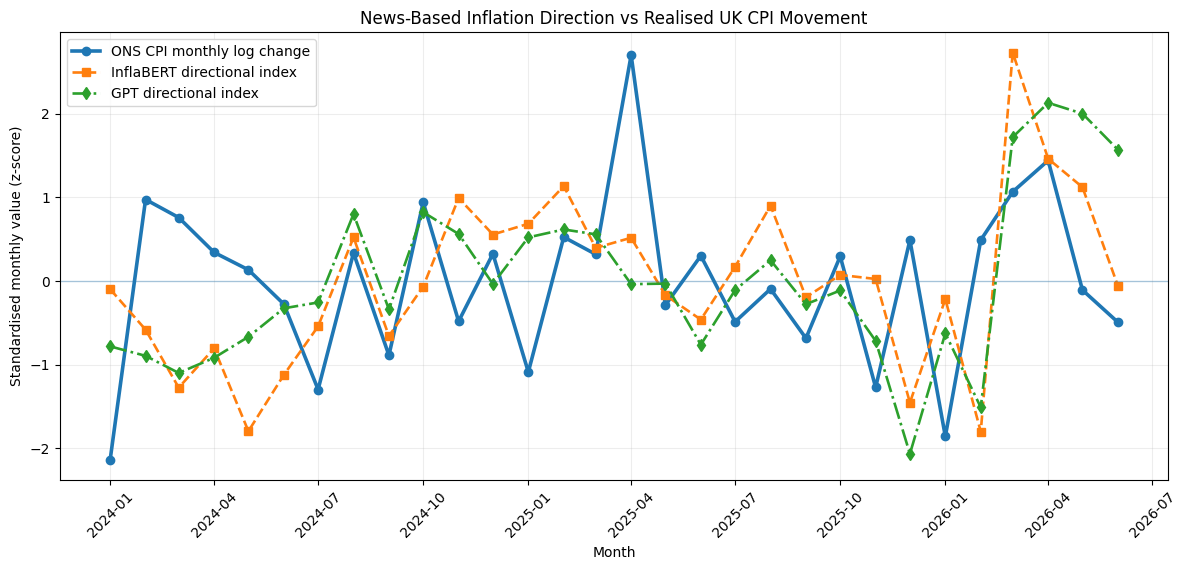

In [ ]:
# Figure 1: directional measures vs realised CPI
fig, ax = plt.subplots(figsize=(12, 5.8))

# CPI = Blue (C0), InflaBERT = Orange (C1), GPT = Green (C2)
ax.plot(comparison_df['Date'], comparison_df['CPI_Z'],
        label='ONS CPI monthly log change', color='C0', linewidth=2.6, marker='o')
ax.plot(comparison_df['Date'], comparison_df['InflaBERT_Z'],
        label='InflaBERT directional index', color='C1', linewidth=1.9, linestyle='--', marker='s')
ax.plot(comparison_df['Date'], comparison_df['GPT_Z'],
        label='GPT directional index', color='C2', linewidth=1.9, linestyle='-.', marker='d')

ax.axhline(0, linewidth=1, alpha=0.35)
ax.set_title('News-Based Inflation Direction vs Realised UK CPI Movement')
ax.set_xlabel('Month')
ax.set_ylabel('Standardised monthly value (z-score)')
ax.grid(alpha=0.22)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

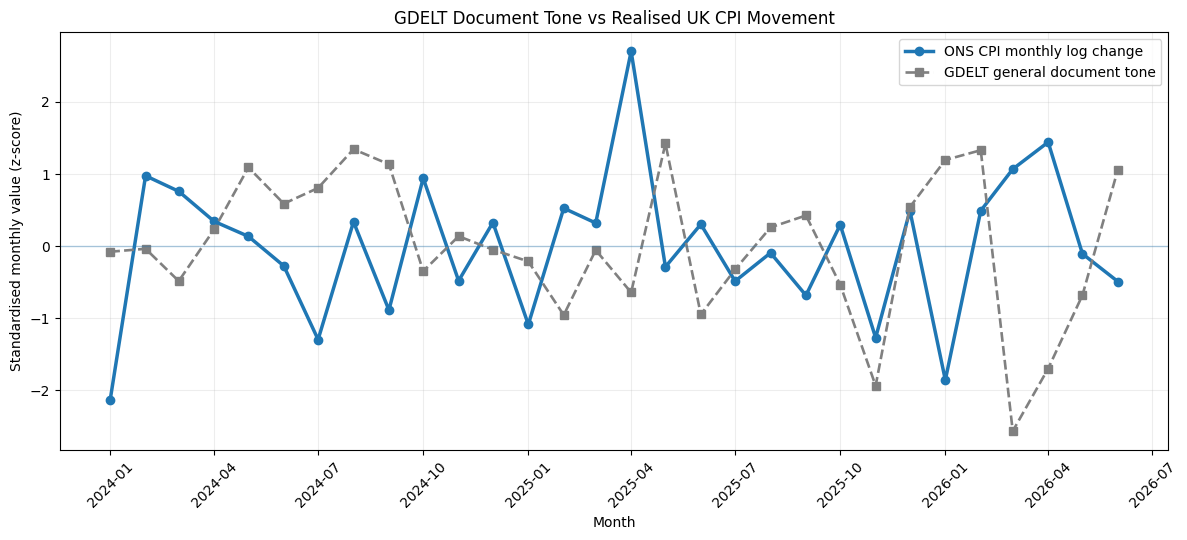

In [ ]:
# Figure 2: GDELT shown separately because it measures general document tone
fig, ax = plt.subplots(figsize=(12, 5.5))

# CPI = Blue (C0), GDELT = Gray
ax.plot(comparison_df['Date'], comparison_df['CPI_Z'],
        label='ONS CPI monthly log change', color='C0', linewidth=2.5, marker='o')
ax.plot(comparison_df['Date'], comparison_df['GDELT_Z'],
        label='GDELT general document tone', color='Gray', linewidth=1.9, linestyle='--', marker='s')

ax.axhline(0, linewidth=1, alpha=0.35)
ax.set_title('GDELT Document Tone vs Realised UK CPI Movement')
ax.set_xlabel('Month')
ax.set_ylabel('Standardised monthly value (z-score)')
ax.grid(alpha=0.22)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

--- Correlation Matrix: Original Monthly Measures ---


,Inflation_Rate_LogDiff,InflaBERT_Polarity,GPT_Label,GDELT_Tone
Inflation_Rate_LogDiff,1.000,0.157,0.175,-0.335
InflaBERT_Polarity,0.157,1.000,0.802,-0.609
GPT_Label,0.175,0.802,1.000,-0.360
GDELT_Tone,-0.335,-0.609,-0.360,1.000


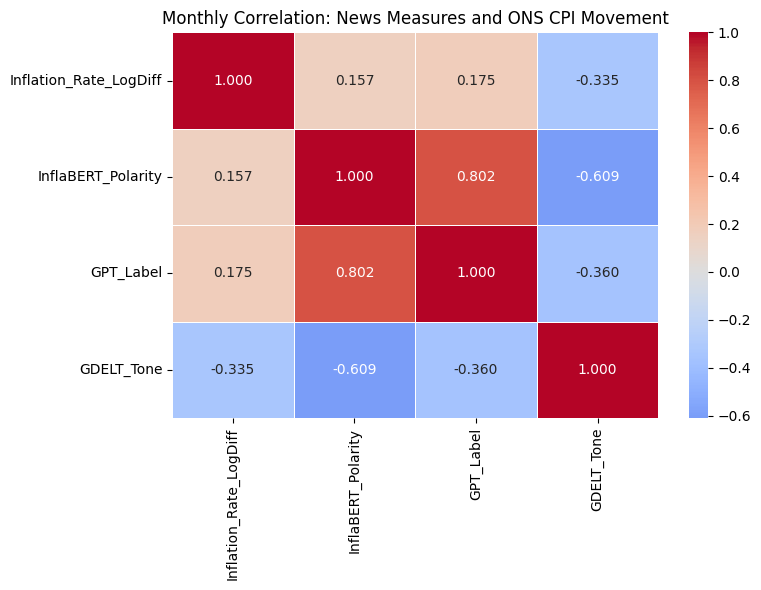

In [ ]:
corr_cols = [
    'Inflation_Rate_LogDiff',
    'InflaBERT_Polarity',
    'GPT_Label',
    'GDELT_Tone'
]
monthly_corr = comparison_df[corr_cols].corr()

print('--- Correlation Matrix: Original Monthly Measures ---')
display(monthly_corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(
    monthly_corr,
    annot=True,
    fmt='.3f',
    center=0,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Monthly Correlation: News Measures and ONS CPI Movement')
plt.tight_layout()
# plt.savefig(OUTPUT_DIR / 'monthly_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# monthly_corr.to_csv(OUTPUT_DIR / 'monthly_correlation_matrix.csv')

## 8. Lead-lag correlation: 0–3 months ahead

The lead-lag test asks whether a news measure in month \(t\) is associated with realised CPI movement in month \(t+k\).

- **Lag 0:** news in month \(t\) vs CPI in the same month.
- **Lag 1:** news in month \(t\) vs CPI one month later.
- **Lag 2:** news in month \(t\) vs CPI two months later.
- **Lag 3:** news in month \(t\) vs CPI three months later.

The same procedure is applied to InflaBERT, GPT and GDELT. Pearson \(r\), its two-sided p-value and the number of aligned monthly observations are reported. These results describe association/lead structure; they are not presented as a standalone forecasting-accuracy claim.

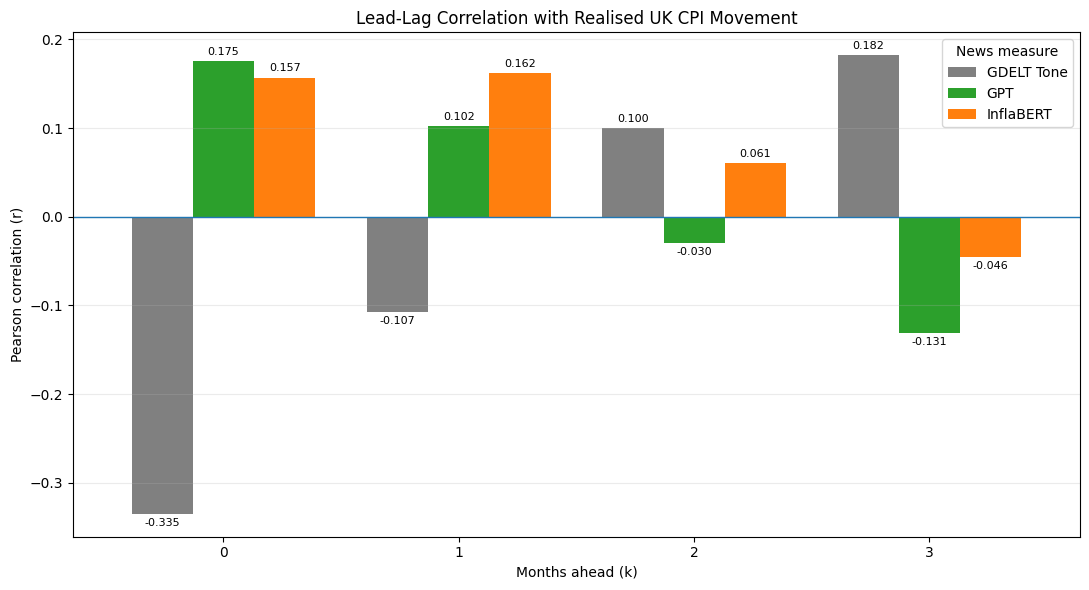

In [ ]:
lead_lag_measures = {
    'InflaBERT': 'InflaBERT_Polarity',
    'GPT': 'GPT_Label',
    'GDELT Tone': 'GDELT_Tone'
}

lead_lag_rows = []

for model_name, column in lead_lag_measures.items():
    for lag in range(4):
        aligned = pd.DataFrame({
            'News': comparison_df[column],
            'Future_CPI': comparison_df['Inflation_Rate_LogDiff'].shift(-lag)
        }).dropna()

        if len(aligned) >= 3 and aligned['News'].nunique() > 1 and aligned['Future_CPI'].nunique() > 1:
            r, p = pearsonr(aligned['News'], aligned['Future_CPI'])
        else:
            r, p = np.nan, np.nan

        lead_lag_rows.append({
            'Measure': model_name,
            'Lag_Months_Ahead': lag,
            'Correlation_r': r,
            'P_Value': p,
            'N': len(aligned)
        })

lead_lag_df = pd.DataFrame(lead_lag_rows)

lag_plot = (
    lead_lag_df
    .pivot(index='Lag_Months_Ahead', columns='Measure', values='Correlation_r')
    .reindex([0, 1, 2, 3])
)

# Consistent mapping: GDELT=Gray, GPT=Green (C2), InflaBERT=Orange (C1)
color_map = {'GDELT Tone': 'Gray', 'GPT': 'C2', 'InflaBERT': 'C1'}
colors = [color_map[col] for col in lag_plot.columns]

ax = lag_plot.plot(kind='bar', figsize=(11, 6), width=0.78, color=colors)
ax.axhline(0, linewidth=1)
ax.set_title('Lead-Lag Correlation with Realised UK CPI Movement')
ax.set_xlabel('Months ahead (k)')
ax.set_ylabel('Pearson correlation (r)')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='News measure')

for patch in ax.patches:
    height = patch.get_height()
    if np.isfinite(height):
        ax.annotate(
            f'{height:.3f}',
            (patch.get_x() + patch.get_width()/2, height),
            ha='center',
            va='bottom' if height >= 0 else 'top',
            fontsize=8,
            xytext=(0, 3 if height >= 0 else -3),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()

## 9. Reference-annotation validation: InflaBERT and GPT

The supplied reference workbook is used to evaluate article-level **inflation direction**. The three reference classes are:

- **UP = +1:** inflation or inflationary pressure is rising / expected to rise.
- **NEUTRAL = 0:** there is no sufficiently clear direction, conditions are stable, or the evidence is genuinely mixed.
- **DOWN = -1:** inflation or inflationary pressure is easing / expected to decline.

The direction label is not general emotional or welfare sentiment. For example, *falling inflation is good news for households* is still **DOWN** on the inflation-direction axis.

Before validation, the text receives the same light cleaning used for the main corpus and **exact duplicate extracted texts are removed** so the same article cannot receive extra weight. In the supplied workbook this produces an evenly balanced reference set.

The validation compares only **InflaBERT and GPT**, because both target inflation direction. GDELT document tone is not treated as the same classification task.

For methodological consistency, the validation texts are **re-scored with the final InflaBERT procedure used in this notebook**. Any older `InflaBERT_Label` column stored in the workbook is retained only for traceability and is not used as the final InflaBERT prediction.


Reference rows before exact-text deduplication: 200
Exact duplicate validation texts removed: 2
Reference rows used after deduplication: 198

Reference class distribution:


,Count
Human_Label,
DOWN,66
NEUTRAL,66
UP,66


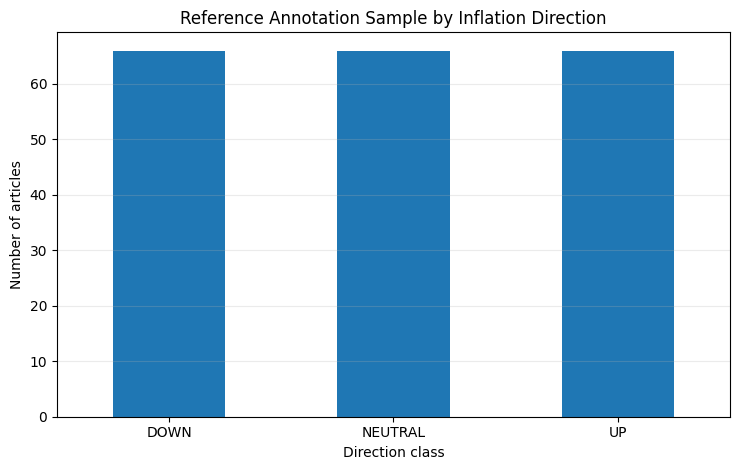


Re-scoring 198 validation articles with the final InflaBERT procedure...


In [ ]:
HUMAN_FILE_CANDIDATES = [
    Path('/content/Human Annotated Sample.xlsx'),
    Path('/content/drive/MyDrive/GDELT/Human Annotated Sample.xlsx')
]

human_file_path = next((p for p in HUMAN_FILE_CANDIDATES if p.exists()), None)

if human_file_path is None:
    raise FileNotFoundError(
        'Validation workbook not found. Upload "Human Annotated Sample.xlsx" to /content '
        'or place it in /content/drive/MyDrive/GDELT/.'
    )

reference = pd.read_excel(human_file_path, sheet_name='Validation_Sample').copy()

required_reference_cols = [
    'ArticleDate',
    'Headline',
    'Extracted Data',
    'Human Annotated'
]
missing_cols = [c for c in required_reference_cols if c not in reference.columns]
if missing_cols:
    raise ValueError(f'Missing required validation columns: {missing_cols}')

reference['Human_Label'] = reference['Human Annotated'].apply(label_to_num)
reference['Validation_Text'] = reference['Extracted Data'].apply(light_clean_text)

reference = reference.dropna(
    subset=['Headline', 'Human_Label', 'Validation_Text']
).copy()
reference = reference[reference['Validation_Text'].str.len() > 0].copy()
reference['Human_Label'] = reference['Human_Label'].astype(int)

# Remove only exact duplicate extracted texts from the validation sample.
reference_rows_before_dedup = len(reference)
reference = reference.drop_duplicates(subset=['Validation_Text'], keep='first').copy()
removed_reference_duplicates = reference_rows_before_dedup - len(reference)

print(f'Reference rows before exact-text deduplication: {reference_rows_before_dedup}')
print(f'Exact duplicate validation texts removed: {removed_reference_duplicates}')
print(f'Reference rows used after deduplication: {len(reference)}')

print('\nReference class distribution:')
reference_dist = (
    reference['Human_Label']
    .map(DIRECTION_NAME)
    .value_counts()
    .reindex(['DOWN', 'NEUTRAL', 'UP'], fill_value=0)
    .rename('Count')
    .to_frame()
)
display(reference_dist)

ax = reference_dist.plot(kind='bar', figsize=(7.5, 4.8), legend=False)
ax.set_title('Reference Annotation Sample by Inflation Direction')
ax.set_xlabel('Direction class')
ax.set_ylabel('Number of articles')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
# plt.savefig(OUTPUT_DIR / 'reference_sample_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nRe-scoring {len(reference)} validation articles with the final InflaBERT procedure...')
validation_results = reference['Validation_Text'].apply(get_softmax_sentiment)

reference['VAL_P_DOWN'], reference['VAL_P_NEUTRAL'], reference['VAL_P_UP'], reference['VAL_InflaBERT_Polarity'] = zip(*validation_results)

validation_prob_cols = ['VAL_P_DOWN', 'VAL_P_NEUTRAL', 'VAL_P_UP']
reference['InflaBERT_Validation_Label'] = direction_values[
    np.argmax(reference[validation_prob_cols].to_numpy(), axis=1)
]


### GPT labels for the reference articles

If the validation workbook already contains a `GPT_Label` column, those labels are used **directly**—no rematching is performed.

For compatibility with the currently supplied workbook, which may not contain that column, the next cell includes a conservative fallback that retrieves the existing GPT label from the original labelled dataset. The fallback prioritises exact cleaned-text identity, then date + headline, and finally a headline-only match **only when that headline is unique** in the source dataset. This is a lookup of an existing label, not a new GPT classification.


In [ ]:
def normalise_headline(text):
    text = light_clean_text(text).lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def parse_mixed_article_dates(series):
    """Parse ordinary dates and Excel serial-date values safely."""
    numeric = pd.to_numeric(series, errors='coerce')
    parsed = pd.to_datetime(series, errors='coerce')

    excel_mask = numeric.notna() & numeric.between(20000, 80000)
    if excel_mask.any():
        parsed.loc[excel_mask] = pd.to_datetime(
            numeric.loc[excel_mask],
            unit='D',
            origin='1899-12-30'
        )
    return parsed

validation_df = reference.copy()

# Preferred path: use the GPT labels already stored in the validation workbook.
if 'GPT_Label' in validation_df.columns:
    validation_df['GPT_Validation_Label'] = validation_df['GPT_Label'].apply(label_to_num)
    print('Using GPT labels directly from the validation workbook.')

else:
    print('GPT_Label is not present in the validation workbook; using a conservative lookup from the original labelled dataset.')

    validation_df['_Text_Key'] = validation_df['Validation_Text']
    validation_df['_Headline_Key'] = validation_df['Headline'].apply(normalise_headline)
    validation_df['_Date_Key'] = parse_mixed_article_dates(
        validation_df['ArticleDate']
    ).dt.strftime('%Y-%m-%d')

    gpt_lookup = raw_df[['ArticleDate', 'Headline', 'Extracted_Text', 'GPT_Label']].copy()
    gpt_lookup['GPT_Label'] = gpt_lookup['GPT_Label'].apply(label_to_num)
    gpt_lookup['_Text_Key'] = gpt_lookup['Extracted_Text'].apply(light_clean_text)
    gpt_lookup['_Headline_Key'] = gpt_lookup['Headline'].apply(normalise_headline)
    gpt_lookup['_Date_Key'] = pd.to_datetime(
        gpt_lookup['ArticleDate'], errors='coerce'
    ).dt.strftime('%Y-%m-%d')

    # 1) Exact cleaned-text match, used only when all identical source rows carry one GPT label.
    text_groups = (
        gpt_lookup.dropna(subset=['_Text_Key', 'GPT_Label'])
        .groupby('_Text_Key')['GPT_Label']
        .agg(['nunique', 'first'])
    )
    text_label_map = text_groups.loc[
        text_groups['nunique'] == 1, 'first'
    ]
    validation_df['GPT_Validation_Label'] = validation_df['_Text_Key'].map(text_label_map)

    # 2) Exact date + normalised headline where that key has one consistent GPT label.
    missing_gpt = validation_df['GPT_Validation_Label'].isna()
    if missing_gpt.any():
        date_headline_groups = (
            gpt_lookup.dropna(subset=['_Date_Key', '_Headline_Key', 'GPT_Label'])
            .groupby(['_Date_Key', '_Headline_Key'])['GPT_Label']
            .agg(['nunique', 'first'])
        )
        date_headline_map = date_headline_groups.loc[
            date_headline_groups['nunique'] == 1, 'first'
        ]

        lookup_keys = list(zip(
            validation_df.loc[missing_gpt, '_Date_Key'],
            validation_df.loc[missing_gpt, '_Headline_Key']
        ))
        validation_df.loc[missing_gpt, 'GPT_Validation_Label'] = [
            date_headline_map.get(key, np.nan) for key in lookup_keys
        ]

    # 3) Headline-only fallback only when the headline occurs once in the source dataset.
    missing_gpt = validation_df['GPT_Validation_Label'].isna()
    if missing_gpt.any():
        headline_groups = (
            gpt_lookup.dropna(subset=['_Headline_Key', 'GPT_Label'])
            .groupby('_Headline_Key')['GPT_Label']
            .agg(['nunique', 'first', 'size'])
        )
        unique_headline_map = headline_groups.loc[
            (headline_groups['size'] == 1) & (headline_groups['nunique'] == 1),
            'first'
        ]
        validation_df.loc[missing_gpt, 'GPT_Validation_Label'] = (
            validation_df.loc[missing_gpt, '_Headline_Key']
            .map(unique_headline_map)
        )

validation_df['GPT_Validation_Label'] = pd.to_numeric(
    validation_df['GPT_Validation_Label'], errors='coerce'
)

print(f'Validation rows after deduplication: {len(validation_df)}')
print(f'GPT labels available: {validation_df["GPT_Validation_Label"].notna().sum()}')
print(f'GPT labels unavailable: {validation_df["GPT_Validation_Label"].isna().sum()}')

if validation_df['GPT_Validation_Label'].isna().any():
    print('\nRows without a safely available GPT label:')
    display(
        validation_df.loc[
            validation_df['GPT_Validation_Label'].isna(),
            ['ArticleDate', 'Headline']
        ]
    )


GPT_Label is not present in the validation workbook; using a conservative lookup from the original labelled dataset.
Validation rows after deduplication: 198
GPT labels available: 198
GPT labels unavailable: 0


## 10. Classification performance against the reference annotations

The evaluation compares each automated inflation-direction label with the reference label **article by article**. The same common rows are used for InflaBERT and GPT. Accuracy is reported alongside Macro Precision, Macro Recall and Macro F1 so **DOWN, NEUTRAL and UP receive equal importance**. Balanced Accuracy and Cohen's kappa are retained as supplementary reliability measures.


In [ ]:
# Fair comparison: use only rows where Reference, final InflaBERT and GPT labels are all available.
eval_df = validation_df.dropna(
    subset=['Human_Label', 'InflaBERT_Validation_Label', 'GPT_Validation_Label']
).copy()

eval_df['Human_Label'] = eval_df['Human_Label'].astype(int)
eval_df['InflaBERT_Validation_Label'] = eval_df['InflaBERT_Validation_Label'].astype(int)
eval_df['GPT_Validation_Label'] = eval_df['GPT_Validation_Label'].astype(int)

print(f'Common validation sample used for both models: N={len(eval_df)}')
print('Reference distribution in the common evaluation sample:')
display(
    eval_df['Human_Label']
    .map(DIRECTION_NAME)
    .value_counts()
    .reindex(['DOWN', 'NEUTRAL', 'UP'], fill_value=0)
    .rename('Count')
    .to_frame()
)

def summarise_classifier(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Macro Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro F1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        "Cohen's Kappa": cohen_kappa_score(y_true, y_pred)
    }

y_true = eval_df['Human_Label']

performance_df = pd.DataFrame([
    summarise_classifier(
        'InflaBERT',
        y_true,
        eval_df['InflaBERT_Validation_Label']
    ),
    summarise_classifier(
        'GPT',
        y_true,
        eval_df['GPT_Validation_Label']
    )
]).set_index('Model')

print('--- Overall Validation Metrics ---')
display(performance_df.round(3))

print('--- InflaBERT Class-Level Report ---')
inf_report = pd.DataFrame(
    classification_report(
        y_true,
        eval_df['InflaBERT_Validation_Label'],
        labels=[-1, 0, 1],
        target_names=['DOWN', 'NEUTRAL', 'UP'],
        output_dict=True,
        zero_division=0
    )
).T
display(inf_report.round(3))

print('--- GPT Class-Level Report ---')
gpt_report = pd.DataFrame(
    classification_report(
        y_true,
        eval_df['GPT_Validation_Label'],
        labels=[-1, 0, 1],
        target_names=['DOWN', 'NEUTRAL', 'UP'],
        output_dict=True,
        zero_division=0
    )
).T
display(gpt_report.round(3))

# performance_df.to_csv(OUTPUT_DIR / 'reference_validation_metrics.csv')
# inf_report.to_csv(OUTPUT_DIR / 'inflabert_classification_report.csv')
# gpt_report.to_csv(OUTPUT_DIR / 'gpt_classification_report.csv')


Common validation sample used for both models: N=198
Reference distribution in the common evaluation sample:


,Count
Human_Label,
DOWN,66
NEUTRAL,66
UP,66


--- Overall Validation Metrics ---


,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Cohen's Kappa
Model,,,,,,
InflaBERT,0.682,0.682,0.723,0.682,0.668,0.523
GPT,0.384,0.384,0.608,0.384,0.265,0.076


--- InflaBERT Class-Level Report ---


,precision,recall,f1-score,support
DOWN,0.784,0.439,0.563,66.000
NEUTRAL,0.593,0.970,0.736,66.000
UP,0.792,0.636,0.706,66.000
accuracy,0.682,0.682,0.682,0.682
macro avg,0.723,0.682,0.668,198.000
weighted avg,0.723,0.682,0.668,198.000


--- GPT Class-Level Report ---


,precision,recall,f1-score,support
DOWN,0.667,0.030,0.058,66.000
NEUTRAL,0.357,1.000,0.526,66.000
UP,0.800,0.121,0.211,66.000
accuracy,0.384,0.384,0.384,0.384
macro avg,0.608,0.384,0.265,198.000
weighted avg,0.608,0.384,0.265,198.000


### Report figure: Accuracy, Precision, Recall and F1

The grouped bar chart presents the four most intuitive validation metrics on the same 0–1 scale.

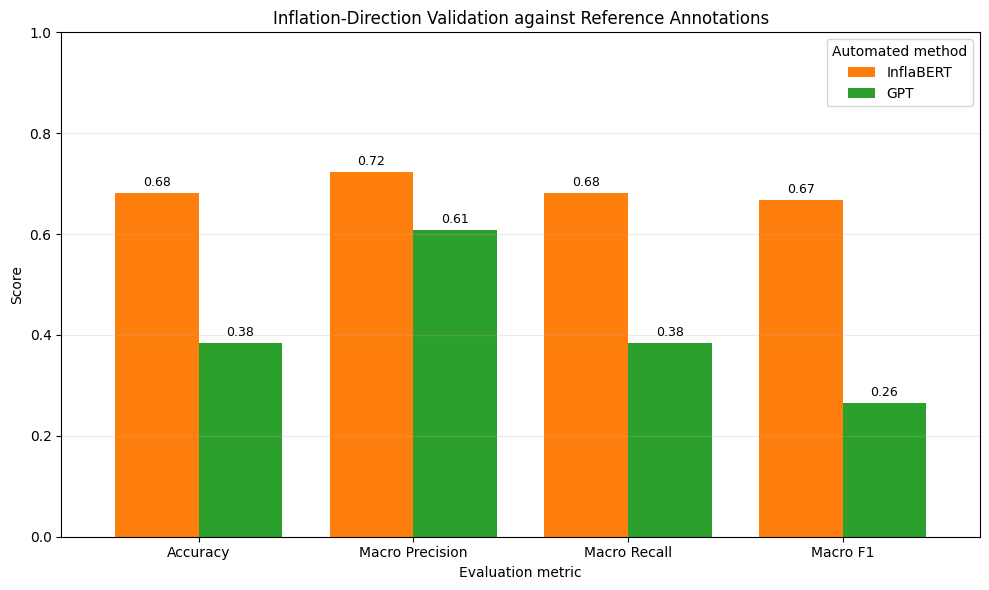

In [ ]:
plot_metrics = performance_df[
    ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
].T

# InflaBERT=Orange (C1), GPT=Green (C2)
ax = plot_metrics.plot(kind='bar', figsize=(10, 6), width=0.78, color=['C1', 'C2'])
ax.set_title('Inflation-Direction Validation against Reference Annotations')
ax.set_xlabel('Evaluation metric')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Automated method')

for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(
        f'{height:.2f}',
        (patch.get_x() + patch.get_width()/2, height),
        ha='center', va='bottom', fontsize=9,
        xytext=(0, 3), textcoords='offset points'
    )

plt.tight_layout()
plt.show()

### Confusion matrices

Rows are the **reference labels** and columns are the model predictions. The diagonal cells (**DOWN→DOWN, NEUTRAL→NEUTRAL, UP→UP**) are agreements. Off-diagonal cells are disagreements. In the figures below, diagonal agreements are highlighted separately from non-zero errors so the pattern is easier to read.


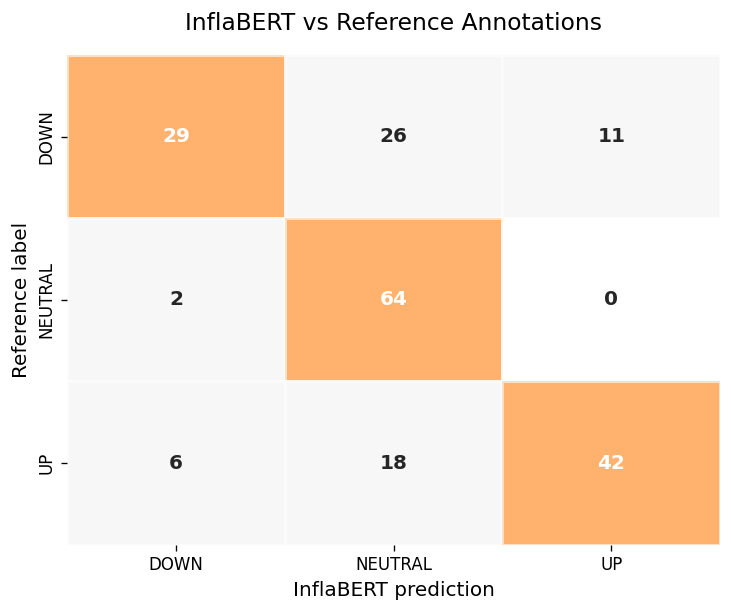

In [ ]:
from matplotlib.colors import ListedColormap

labels = [-1, 0, 1]
display_names = ['DOWN', 'NEUTRAL', 'UP']

def plot_agreement_confusion_matrix(cm, title, prediction_axis_label, color_code):
    """
    White = zero off-diagonal errors
    Light gray = non-zero disagreement
    color_code = diagonal agreement (C1 for InflaBERT, C2 for GPT)
    """
    diagonal = np.eye(len(cm), dtype=bool)
    status = np.where(diagonal, 2, np.where(cm > 0, 1, 0))

    if color_code.startswith('C'):
        main_color = plt.colormaps['tab10'](int(color_code[1]))
    else:
        main_color = color_code

    # Using a neutral light gray for disagreements instead of red
    cmap = ListedColormap(['white', '#f2f2f2', main_color])

    # Increased DPI for high-resolution, non-blurry output
    plt.figure(figsize=(6.2, 5.2), dpi=120)
    sns.heatmap(
        status,
        annot=cm,
        fmt='d',
        cmap=cmap,
        vmin=0,
        vmax=2,
        cbar=False,
        linewidths=1.5,
        linecolor='white',
        xticklabels=display_names,
        yticklabels=display_names,
        annot_kws={'fontsize': 12, 'fontweight': 'bold'},
        alpha=0.6
    )
    plt.title(title, fontsize=14, pad=15)
    plt.xlabel(prediction_axis_label, fontsize=12)
    plt.ylabel('Reference label', fontsize=12)
    plt.tight_layout()
    plt.show()

inf_cm = confusion_matrix(
    y_true,
    eval_df['InflaBERT_Validation_Label'],
    labels=labels
)

# Using C1 (Orange) for InflaBERT
plot_agreement_confusion_matrix(
    inf_cm,
    'InflaBERT vs Reference Annotations',
    'InflaBERT prediction',
    'C1'
)

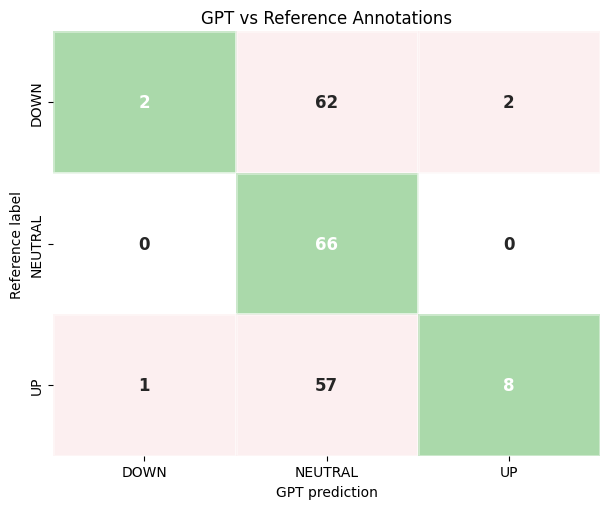

In [ ]:
gpt_cm = confusion_matrix(
    y_true,
    eval_df['GPT_Validation_Label'],
    labels=labels
)

# Using C2 (Green) for GPT to maintain notebook-wide consistency
plot_agreement_confusion_matrix(
    gpt_cm,
    'GPT vs Reference Annotations',
    'GPT prediction',
    'C2'
)

# plt.savefig(...) can be added here if OUTPUT_DIR is later enabled.

## 11. Final outputs and interpretation boundary

This final notebook supports three claims only:

1. **Label reliability:** how closely InflaBERT and GPT agree with the supplied reference annotations.
2. **Contemporaneous association:** how the monthly news measures co-move with realised ONS CPI movement.
3. **Short lead structure:** whether the strongest association occurs contemporaneously or at 1–3 months ahead.

Low correlations are valid results. They should not be presented as model failure or converted into stronger forecasting claims. CPI is produced from a broad basket of observed prices and is affected by many economic forces that are not represented by a news index.

The notebook deliberately does **not** use RMSE/MAE, AR/ADL, AIC/BIC, SVM, Random Forest or Logistic Regression as final validation steps, because those analyses do not directly answer the final research questions adopted here.

In [ ]:
# Optional report-output saving.
# Leave this cell commented while OUTPUT_DIR is disabled.
# When needed, uncomment OUTPUT_DIR in Cell 2 and then uncomment the lines below.

# comparison_df.to_csv(
#     OUTPUT_DIR / 'monthly_news_indices_with_ons_cpi.csv',
#     index=False
# )

# lead_lag_df.to_csv(
#     OUTPUT_DIR / 'lead_lag_three_measures.csv',
#     index=False
# )

# performance_df.to_csv(
#     OUTPUT_DIR / 'reference_validation_metrics.csv'
# )

# inf_report.to_csv(
#     OUTPUT_DIR / 'inflabert_classification_report.csv'
# )

# gpt_report.to_csv(
#     OUTPUT_DIR / 'gpt_classification_report.csv'
# )

# eval_export_cols = [
#     c for c in [
#         'ArticleDate',
#         'Month',
#         'Headline',
#         'Human Annotated',
#         'Human_Label',
#         'InflaBERT_Label',
#         'InflaBERT_Validation_Label',
#         'GPT_Validation_Label'
#     ]
#     if c in eval_df.columns
# ]

# eval_df[eval_export_cols].to_csv(
#     OUTPUT_DIR / 'reference_validation_article_level.csv',
#     index=False
# )

# print('Saved report-ready outputs:')
# for path in sorted(OUTPUT_DIR.iterdir()):
#     print('-', path)
